[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Factory Inventory Management System**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

## Project Overview  
The Factory Inventory Management System is an automated computer vision solution designed to track and count industrial assets in real time.  
Built on the **YOLOv11 segmentation framework**, the system identifies cargo bags on moving conveyor belts with pixel-level precision.

The system uses a **directional tripwire logic** to ensure accurate counting and prevent duplicate detections.

---

## Core Workflow  

### Tracking  
Uses **YOLOv11-seg** with object tracking to assign a unique ID to every cargo bag.  
This ensures each item is counted only once.

---

### Directional Logic  
A custom vertical tripwire (e.g., `LINE_X = 887`) monitors the center point of each detected object.

---

### Trigger Mechanism  
The counter increments only when a bag moves:
- From the **right side** of the line  
- To the **left side** of the line  

This prevents false counts caused by conveyor vibrations or object movement fluctuations.

---

### Visual Interface  
A high-contrast black dashboard is displayed at the top-left corner of the video feed, showing the live inventory count in real time.

---

## Real-World Applications  

### Automated Throughput Monitoring  
Replaces manual counting with a digital and accurate tracking system.

### Bottleneck Detection  
Tracks production speed and identifies slowdowns in conveyor flow.

### Inventory Reconciliation  
Matches physical output with ERP or warehouse inventory records.

### Quality & Safety Monitoring  
Detects damaged or misplaced bags to reduce conveyor jams and operational risks.

---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.*** 



## Import Libraries

This section imports all the required libraries used throughout the project for computer vision, visualization, deep learning, and structured coding.


In [1]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

Cloning into 'yolo_finetune_utils'...


In [2]:
!pip install ultralytics opencv-python matplotlib cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cv2


## 🎞️ Random Frame Extraction from Video

Extracts a fixed number of high-quality frames from one or more videos to create an image dataset for annotation and training.

### 🔹 Purpose
- Convert raw manufacturing videos into individual image frames  
- Perform random sampling to avoid frame bias  
- Prepare data for annotation and YOLO training  


In [10]:
%pip install tqdm

from yolo_finetune_utils.frame_extractor import extract_random_frames

extract_random_frames(
    paths=['4855587-hd_1920_1080_30fps.mp4'],
    total_images=25,
    out_dir="dataset_Frames",
    jpg_quality=100,
    seed=42
)


[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
[✓] Extracted 25 frames to folder: dataset_Frames


## 📥 Download Annotations from Labellerr

After completing data labeling on the **Labellerr** platform, export the annotations in **COCO JSON format**.

Download the COCO JSON file from the Labellerr website and upload it into this project workspace to use it for further dataset preparation and training.

This COCO JSON file will be used in the next steps for:
- Frame–annotation alignment
- COCO → YOLO format conversion
- Model training and evaluation


# COCO to YOLO Format Conversion

Converts COCO-style segmentation annotations to YOLO segmentation dataset format.  
- Requires: `annotation.json` and images in `frames_output` directory.
- Output: Generated YOLO dataset folder.
- Parameters: allows train/val split, shuffling, and verbose mode.


In [13]:
from yolo_finetune_utils.coco_yolo_converter.seg_converter import coco_to_yolo_converter

coco_to_yolo_converter(
    json_path="a3876255-8ff3-4798-aeca-d8cc01cf4d1e.json",
    images_dir="dataset_Frames",
    output_dir="yolo_finalist_Dataset",
    use_split=True,
    train_ratio=0.9,
    val_ratio=0.1,
    test_ratio=0,
    shuffle=True,
    verbose=True
)

Conversion complete. Stats: {'train': 22, 'val': 2, 'test': 1}


{'stats': {'train': 22, 'val': 2, 'test': 1},
 'output_dir': 'yolo_finalist_Dataset'}

# Load and Train YOLO Segmentation Model

Loads the YOLO segmentation model and trains it using the converted YOLO dataset.
- Data: Path to YOLO-style `data.yaml`
- Parameters: epochs, image size, batch size, device, dataloader workers, experiment name.


In [ ]:
# Initialize the Extra Large model
model = YOLO('yolo11n-seg.pt') 

results = model.train(
    data='/kaggle/working/ydata.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    project='/kaggle/working/actory',
    name='train_run_11',
    device=0     # 50% chance to flip upside-down
)

# YOLOv11 Instance Segmentation: Single Frame Inference
 
This script performs **single-frame inference** using a custom-trained YOLOv11 segmentation model.  
It extracts a specific frame from a video and applies instance segmentation to verify the predictions.


0: 384x640 3 Cargo Bags, 158.4ms
Speed: 7.5ms preprocess, 158.4ms inference, 39.8ms postprocess per image at shape (1, 3, 384, 640)


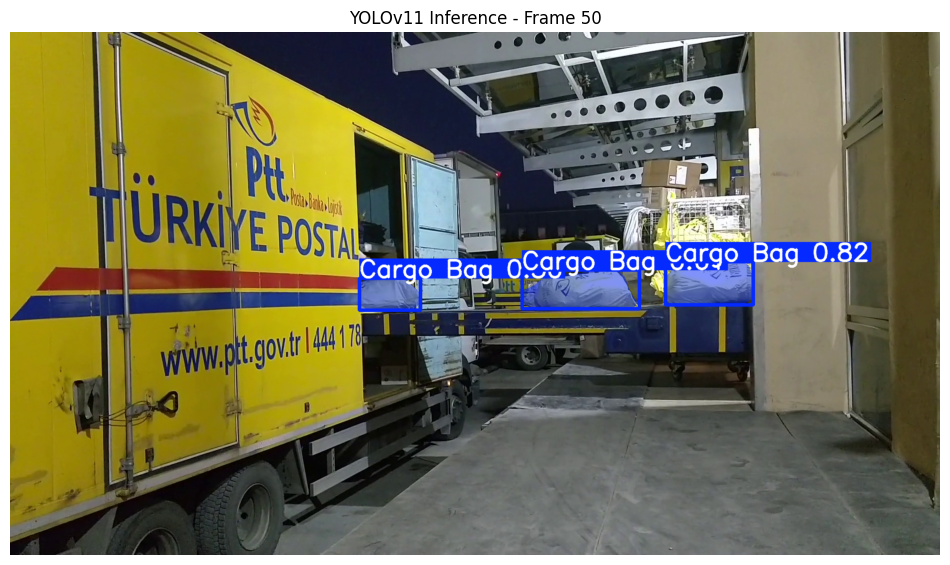

In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load your custom trained waste model
model = YOLO('best (17).pt') 

# 2. Path to your video file
video_path = '4855587-hd_1920_1080_30fps.mp4'
cap = cv2.VideoCapture(video_path)

# 3. Jump to the 700th frame
frame_no = 50
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
success, frame = cap.read()

if success:
    # 4. Run inference
    results = model.predict(
        source=frame, 
        conf=0.3,
        retina_masks=True,
        show_boxes=False,
        show_labels=True
    )

    # 5. Get the annotated frame (OpenCV uses BGR)
    annotated_frame = results[0].plot()

    # 6. Convert BGR to RGB for Matplotlib (OpenCV colors are swapped)
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    # 7. Display directly in VS Code output
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off')  # Hide the X and Y axis numbers
    plt.title(f"YOLOv11 Inference - Frame {frame_no}")
    plt.show()
    
else:
    print(f"Error: Frame {frame_no} not found.")

cap.release()

# Tracking & Segmentation Pipeline

- Loads a custom-trained **YOLOv11-seg** model for cargo bag segmentation.  
- Uses `model.track()` to assign unique IDs and prevent duplicate counts.  
- Enables `retina_masks=True` for high-resolution segmentation masks.  
- Hides boxes and labels for a clean visual output.  
- Uses `stream=True` for memory-efficient frame-by-frame processing.  

---

In [ ]:
from ultralytics import YOLO

# 1. Load your newly trained custom model
# Make sure "best.pt" is in the same directory, or provide the full path
model = YOLO("/kaggle/working/actory/train_run_11-2/weights/best.pt") 

video_path = "/kaggle/input/datasets/aaryanaggarwal5040/factory-vid/4855587-hd_1920_1080_30fps.mp4" # Update this to your actual video file name

print(f"Starting inference on {video_path}...")
results = model.track(
    source=video_path,
    save=True, 
    conf=0.3,
    show_boxes=False,    # Keep this False to hide the rectangles
    show_labels=False,    # Keep this True to see the names
    show_conf=False,
    retina_masks=True,
    stream=True,
    verbose=True,
    # --- ADD THIS TO SHRINK THE TEXT ---
    line_width=2         # This will make the font significantly smaller and thinner
)

# 3. Execute the video processing loop
# Because stream=True creates a generator, we must iterate through it to process the video
for frame_result in results:
    pass 

print("\nInference complete!")
print("Look for your newly generated video inside the 'runs/segment/predict/' folder.")

# Functional Overview

- Extracts a video frame for line calibration.  
- Draws a fixed vertical line using mouse clicks.  
- Shows live points, line preview, and coordinates.  
- `q` saves the line, `r` resets the selection.  
- Outputs `LINE_X`, `LINE_Y_START`, and `LINE_Y_END` for the main script.

---

In [ ]:
import cv2
import numpy as np

# 1. Setup paths
video_path = "4855587-hd_1920_1080_30fps.mp4" 
points = []

# 2. Callback to enforce vertical constraint
def draw_vertical_line(event, x, y, flags, param):
    global points
    if event == cv2.EVENT_LBUTTONDOWN:
        if len(points) == 0:
            # First click: Capture both X and Y
            points.append((x, y))
            print(f"Start Point set: ({x}, {y})")
        elif len(points) == 1:
            # Second click: Keep X from the first point, capture new Y
            fixed_x = points[0][0]
            points.append((fixed_x, y))
            print(f"End Point set: ({fixed_x}, {y}) (Vertical constraint applied)")
        else:
            print("Line already defined. Press 'r' to reset.")

# 3. Extract the frame
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 4)
success, frame = cap.read()
cap.release()

if not success:
    print("Error: Could not open video.")
else:
    cv2.namedWindow("Define Vertical Counting Line")
    cv2.setMouseCallback("Define Vertical Counting Line", draw_vertical_line)

    print("--- INSTRUCTIONS ---")
    print("1. Click where you want the line to START (Top).")
    print("2. Click where you want the line to END (Bottom).")
    print("   *The X coordinate will automatically stay the same as the first click.*")
    print("3. Press 'q' to save or 'r' to reset.")

    while True:
        temp_frame = frame.copy()
        
        # Draw the points and the line
        for pt in points:
            cv2.circle(temp_frame, pt, 5, (0, 0, 255), -1)
        
        if len(points) == 2:
            cv2.line(temp_frame, points[0], points[1], (0, 255, 0), 3)
            # Display current coordinates for your script
            cv2.putText(temp_frame, f"LINE_X = {points[0][0]}", (50, 50), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        cv2.imshow("Define Vertical Counting Line", temp_frame)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('r'):
            points = []
            print("Resetting points.")

    cv2.destroyAllWindows()

    # 4. Final Output for your Counting Script
    if len(points) == 2:
        print("\n--- COPY THESE VALUES TO YOUR COUNTING SCRIPT ---")
        print(f"LINE_X = {points[0][0]}")
        print(f"LINE_Y_START = {min(points[0][1], points[1][1])}")
        print(f"LINE_Y_END = {max(points[0][1], points[1][1])}")
    else:
        print("Line selection incomplete.")

--- INSTRUCTIONS ---
1. Click where you want the line to START (Top).
2. Click where you want the line to END (Bottom).
   *The X coordinate will automatically stay the same as the first click.*
3. Press 'q' to save or 'r' to reset.


# Core Logic Breakdown

- Loads a custom **YOLOv11-seg** model for cargo bag segmentation.  
- Uses `model.track(persist=True)` for unique object tracking.  
- Counts bags only when crossing `LINE_X` in the correct direction.  
- Uses `retina_masks=True` for high-quality masks.  
- Displays a clean real-time counter with a high-contrast UI box.

---

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# 1. Load the model and video
model_path = "/kaggle/input/datasets/aaryanaggarwal5040/best-pt-for-factory/best (17).pt"
model = YOLO(model_path) 

video_path = "/kaggle/input/datasets/aaryanaggarwal5040/factory-vid/4855587-hd_1920_1080_30fps.mp4"
output_path = "/kaggle/working/counted_output_with_ui.mp4"

# 2. Setup Tracking & Line Logic
LINE_X = 887
LINE_Y_START = 445
LINE_Y_END = 671

counter = 0
prev_positions = {} 

cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

print(f"Processing video: {video_path}")

# 3. Inference Loop
results = model.track(
    source=video_path, 
    stream=True, 
    conf=0.25, 
    persist=True,
    retina_masks=True 
)

for r in results:
    # Get frame with masks drawn (hiding standard boxes/labels)
    frame = r.plot(boxes=False, labels=False)
    
    # Draw Vertical Counting Line
    cv2.line(frame, (LINE_X, LINE_Y_START), (LINE_X, LINE_Y_END), (0, 0, 255), 4)

    # Counting Logic
    if r.boxes.id is not None:
        boxes = r.boxes.xyxy.cpu().numpy()
        track_ids = r.boxes.id.int().cpu().tolist()

        for box, track_id in zip(boxes, track_ids):
            cx = int((box[0] + box[2]) / 2)
            cy = int((box[1] + box[3]) / 2)

            if track_id in prev_positions:
                old_x = prev_positions[track_id]
                if old_x >= LINE_X and cx < LINE_X:
                    if LINE_Y_START <= cy <= LINE_Y_END:
                        counter += 1
            prev_positions[track_id] = cx

    # --- UI: BLACK BOX & COUNTER ---
    # Create the background rectangle (Top Left)
    # Coordinates: (x1, y1), (x2, y2), Color (BGR), -1 for filled
    cv2.rectangle(frame, (30, 30), (550, 150), (0, 0, 0), -1)
    
    # Place the text inside the box
    cv2.putText(frame, f"Cargo Count: {counter}", (50, 110), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.8, (255, 255, 255), 4)

    out.write(frame)

cap.release()
out.release()
print(f"Inference complete! Output: {output_path}")

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
